In [1]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("dair-ai/emotion")
label_names = dataset["train"].features["label"].names

df = pd.DataFrame(dataset["train"])
print(df["label"].value_counts())

label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64


In [2]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [3]:
## Tokenization

from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=64)

tokenized = dataset.map(tokenize, batched=True)
tokenized

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [4]:
from transformers import AutoModelForSequenceClassification
import evaluate
import numpy as np

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_weighted": f1.compute(predictions=preds, references=labels, average="weighted")["f1"]
    }

In [6]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    compute_metrics=compute_metrics
)

trainer.train()

c:\Users\TrunkSam\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.609121,0.200775,0.927500,0.928239
2,0.169215,0.148969,0.940500,0.940165
3,0.116937,0.145599,0.936500,0.936436


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\TrunkSam\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\TrunkSam\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1500, training_loss=0.2984243876139323, metrics={'train_runtime': 3870.143, 'train_samples_per_second': 12.403, 'train_steps_per_second': 0.388, 'total_flos': 794861088768000.0, 'train_loss': 0.2984243876139323, 'epoch': 3.0})

c:\Users\TrunkSam\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       581
         joy       0.94      0.96      0.95       695
        love       0.87      0.79      0.83       159
       anger       0.95      0.90      0.92       275
        fear       0.90      0.88      0.89       224
    surprise       0.70      0.83      0.76        66

    accuracy                           0.93      2000
   macro avg       0.88      0.89      0.88      2000
weighted avg       0.93      0.93      0.93      2000



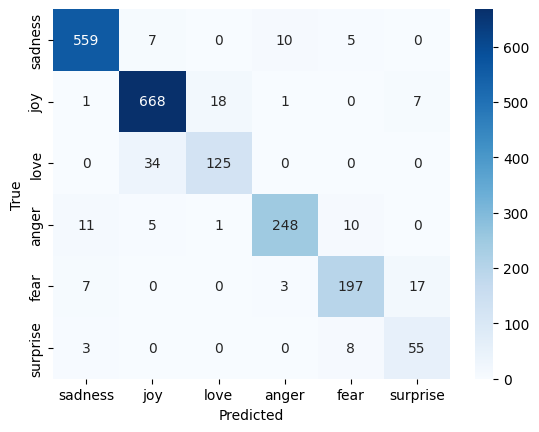

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

preds = trainer.predict(tokenized["test"])
pred = np.argmax(preds.predictions, axis=1)
y_true = tokenized["test"]["label"]

print(classification_report(y_true, pred, target_names=label_names))

cm = confusion_matrix(y_true, pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [8]:
from huggingface_hub import login
login()

In [10]:
model.push_to_hub("TrunkSam/support-emotion-classifier")
tokenizer.push_to_hub("TrunkSam/support-emotion-classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

KeyboardInterrupt: 